### Análisis de datos II
# Clase 1 - Interpretabilidad global

### Clasificación multiclase

Vamos a trabajar con el dataset de Penguins y un problema de clasificación, que consiste en predecir la especie del pingüino.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import xgboost as xgb
from sklearn.metrics import accuracy_score,confusion_matrix, ConfusionMatrixDisplay

from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import partial_dependence

from alibi.explainers import ALE
from alibi.explainers import plot_ale

## Dataset

In [2]:
# Dataset
penguins = sns.load_dataset("penguins").dropna()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


### Entrenamos un modelo de regresión logística

In [3]:
# Variables predictoras y target
X = penguins.copy()
target = "species"

X = penguins.drop(columns=target)
y = penguins[target]

# Columnas categóricas y numéricas
categorical_features = ["island", "sex"]
numeric_features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

In [4]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

# Transformación
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

feature_names_clean = [
    name.replace("cat__", "").replace("num__", "")
    for name in preprocessor.get_feature_names_out()
]

In [5]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

model.fit(X_train_trans, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['Adelie','Chinstrap','Gentoo']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [6]:
coef = model.named_steps["classifier"].coef_

pd.DataFrame(
    coef,
    columns=feature_names_clean,
    index=model.classes_ # multiclase
    # index=[model.classes_[1]] # clasif. binaria
)

,island_Biscoe,island_Dream,island_Torgersen,sex_Female,sex_Male,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
Adelie,0.063050,-0.324719,0.384220,-0.368763,0.368763,-2.292958,0.925342,-0.682557,-0.183478
Chinstrap,-0.726547,0.897679,-0.224757,0.298319,-0.298319,1.858358,0.091294,-0.181571,-0.629669
Gentoo,0.663497,-0.572960,-0.159463,0.070444,-0.070444,0.434600,-1.016637,0.864128,0.813147


In [7]:
y_pred = model.predict(X_test_trans)

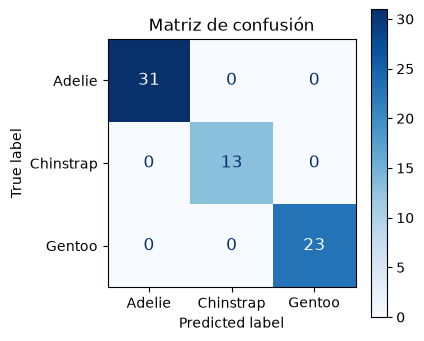


Accuracy: 1.0000


In [8]:
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    ax=ax,
    cmap="Blues",
    text_kw={"fontsize": 12}
)
ax.set_title("Matriz de confusión")
plt.show()

acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc:.4f}")

---
### Permutation Feature Importance (PFI)

In [9]:
model_pfi = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

In [10]:
result = permutation_importance(
    model_pfi,
    X_test,
    y_test,
    scoring="accuracy",
    n_repeats=10,
    random_state=42
)

In [11]:
pfi = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean,
    "std": result.importances_std
})

pfi = pfi.sort_values("importance", ascending=False)

pfi

,feature,importance,std
1,bill_length_mm,0.271642,0.041577
0,island,0.129851,0.030624
2,bill_depth_mm,0.019403,0.011657
3,flipper_length_mm,0.001493,0.004478
5,sex,0.001493,0.004478
4,body_mass_g,0.000000,0.000000


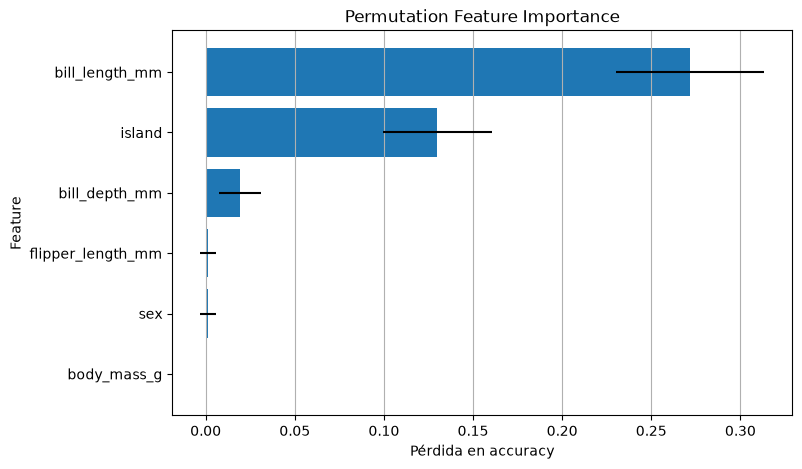

In [12]:
plt.figure(figsize=(8, 5))

plt.barh(
    pfi["feature"],
    pfi["importance"],
    xerr=pfi["std"]
)

plt.xlabel("Pérdida en accuracy")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")

plt.grid(axis='x')
plt.gca().invert_yaxis()
plt.show()

---
### Partial Dependence Plot con respecto a la longitud de la aleta

En un problema de clasificación multiclase podemos hacer el PDP sobre la probabilidad de cada una de las clases por separado.

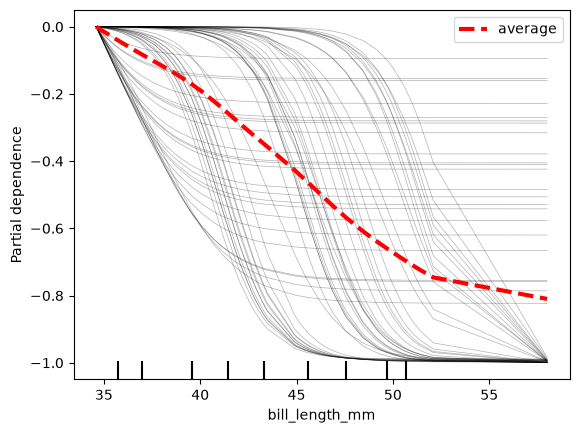

In [13]:
features = ["bill_length_mm"]

PartialDependenceDisplay.from_estimator(
    model,
    X_test_trans,
    kind='both',
    features=features,
    feature_names=feature_names_clean,
    target='Adelie',
    centered=True,
    ice_lines_kw={"color": "black"},
    pd_line_kw={"color": "red","lw":3,'linestyle':'--'}
)

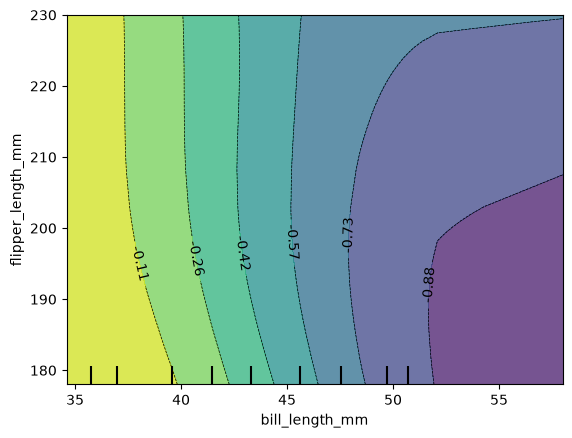

In [14]:
features = [("bill_length_mm", "flipper_length_mm")]

PartialDependenceDisplay.from_estimator(
    model,
    X_test_trans,
    features=features,
    feature_names=feature_names_clean,
    target='Adelie',
    centered=True)

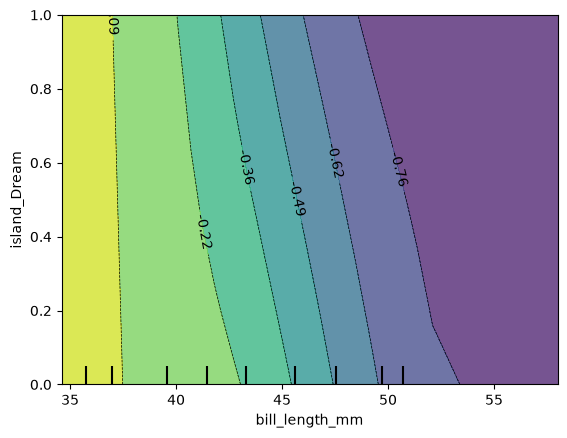

In [15]:
features = [("bill_length_mm", "island_Dream")]

PartialDependenceDisplay.from_estimator(
    model,
    X_test_trans,
    features=features,
    feature_names=feature_names_clean,
    target='Adelie',
    centered=True)

---
### ALE

### ALE en el espacio logit

In [16]:
feature_names = X_train.columns.tolist()

def logit_fun(X):
    X = pd.DataFrame(X, columns=feature_names)
    X_trans = preprocessor.transform(X)
    return model.decision_function(X_trans)

logit_ale = ALE(
    logit_fun,
    feature_names=feature_names,
    target_names=model.classes_
)

logit_exp = logit_ale.explain(
    X_train.to_numpy(),
    features=[1,2,3,4]
)

Veamos cómo varía el efecto de las distintas variables o features según la clase.

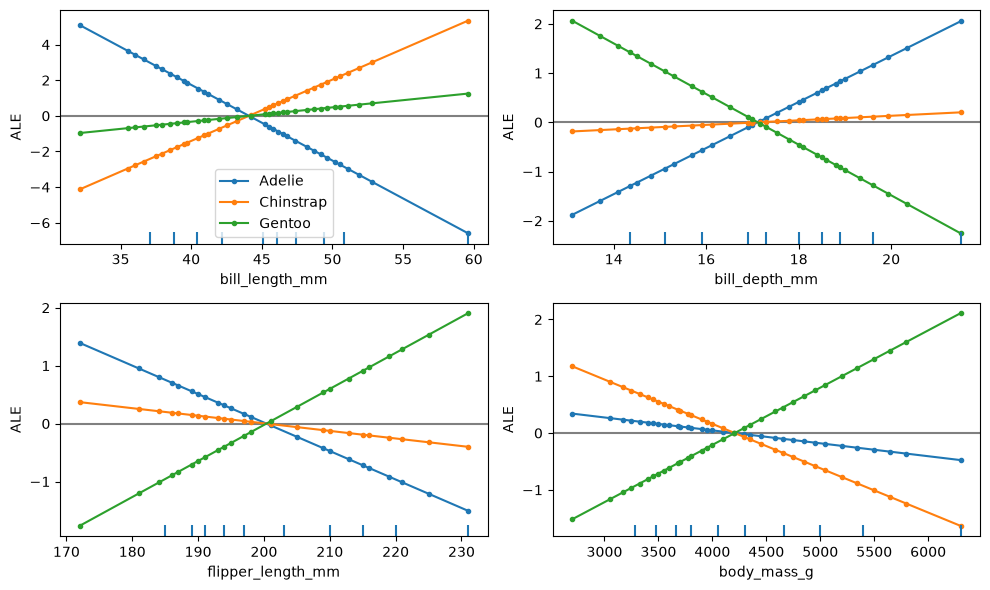

In [17]:
plot_ale(logit_exp, n_cols=2, fig_kw={'figwidth': 10, 'figheight': 6}, sharey=None);

**OBSERVACIONES**:

 - Vemos que los efectos son lineales para todas las clases y para cada feature. Esto es esperable porque la regresión logística es un modelo lineal.
 - La pendiente de cada curva ALE determina el efecto relativo (en logits) de la feature en la predición de cada clase.
 - En particular, la longitud del pico `bill_length_mm` tienen poca variación relativa en su efecto hacia la clase `Gentoo`.
 - Por otro lado, para las clases `Adelie` y `Chinstrap` las pendientes de las curvas son significativas. El efecto relativo sube o baja a medida que el valor de la feature crece.
 - El efecto de la feature en las clases `Adelie` y `Chinstrap` está inversamente relacionado. Esto sugiere que el efecto de picos más largos contribuye más positivamente a predecir `Chinstrap` y negativamente a predecir `Adelie`.

### ALE en el espacio de probabilidades

¿Cómo cambia la probabilidad predicha de cada clase cuando cambia la variable?

In [18]:
model.classes_

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [19]:
def proba_fun(X):
    X = pd.DataFrame(X, columns=feature_names)
    X_trans = preprocessor.transform(X)
    # return model.predict_proba(X_trans)[:, 0] # una clase específica
    return model.predict_proba(X_trans) # todas las clases

proba_ale = ALE(
    proba_fun,
    feature_names=feature_names,
    target_names=model.classes_
)

proba_exp = proba_ale.explain(
    X_train.to_numpy(),
    features=[1, 2, 3, 4]
)

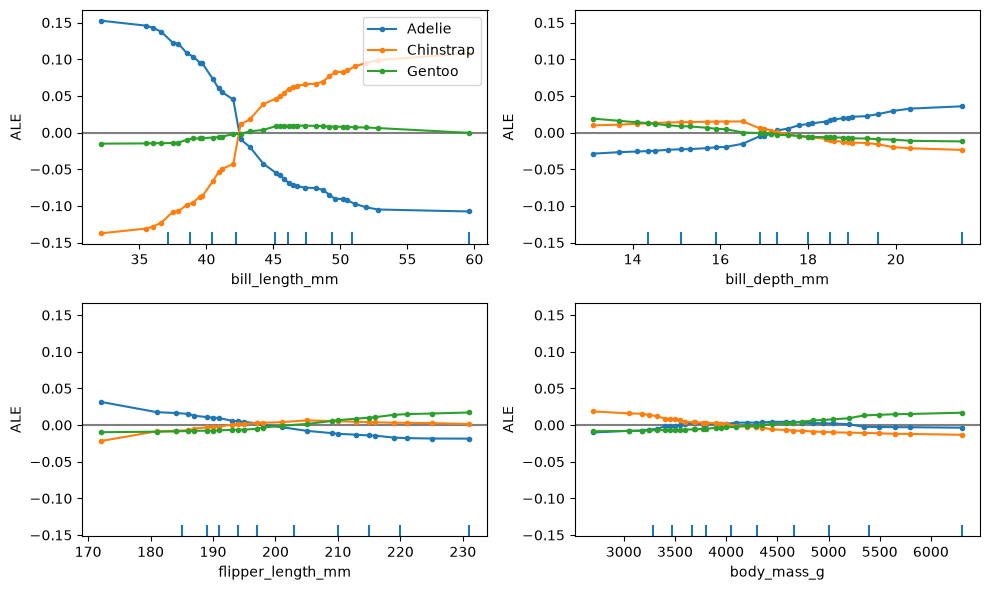

In [20]:
plot_ale(proba_exp, n_cols=2, fig_kw={'figwidth': 10, 'figheight': 6});

**OBSERVACIONES**

La curva ALE para la feature `flipper_length_mm` y la clase `Adelie` es prácticamente plana. Esto significa que el modelo no usa esta feature para asignar más (o menos) probabilidad a la clase `Adelie` con respecto al efecto promedio de la feature. Esto en el espacio logit no se ve.

Aún cuando la curva ALE en el espacio logit muestra un efecto negativo, este no es suficientemente significativo para trasladarlo al espacio de probabilidades.

---
### Entrenamos un Gradient Boosting

Vamos a entrenar y ver los resultados de ALE para un modelo no lineal: Gradient Boosting.

In [21]:
from sklearn.ensemble import GradientBoostingClassifier

In [22]:
gb = GradientBoostingClassifier()
gb.fit(X_train_trans, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"init init: estimator or 'zero', default=NoneAn estimator object that is used to co

In [23]:
y_pred = gb.predict(X_test_trans)

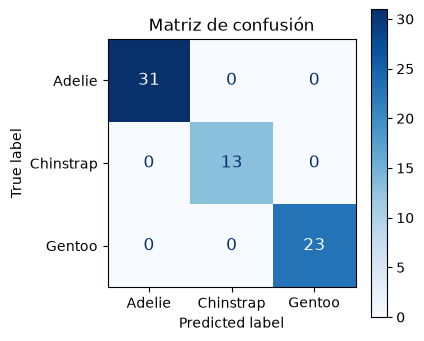


Accuracy: 1.0000


In [24]:
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    ax=ax,
    cmap="Blues",
    text_kw={"fontsize": 12}
)
ax.set_title("Matriz de confusión")
plt.show()

acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc:.4f}")

## ALE

Explicamos las contribuciones de las features, tanto en el espacio logit como en el de probabilidades.

In [25]:
def logit_fun_gb(X):
    X = pd.DataFrame(X, columns=feature_names)
    X_trans = preprocessor.transform(X)
    return gb.decision_function(X_trans)

def proba_fun_gb(X):
    X = pd.DataFrame(X, columns=feature_names)
    X_trans = preprocessor.transform(X)
    return gb.predict_proba(X_trans)

In [26]:
logit_ale_gb = ALE(logit_fun_gb, feature_names=feature_names, target_names=gb.classes_)
proba_ale_gb = ALE(proba_fun_gb, feature_names=feature_names, target_names=gb.classes_)

In [27]:
def logit_fun(X):
    X = pd.DataFrame(X, columns=feature_names)
    X_trans = preprocessor.transform(X)
    return model.decision_function(X_trans)

def proba_fun(X):
    X = pd.DataFrame(X, columns=feature_names)
    X_trans = preprocessor.transform(X)
    return model.predict_proba(X_trans)

In [28]:
logit_exp_gb = logit_ale_gb.explain(X_train.to_numpy(), features=[1, 2, 3, 4])
proba_exp_gb = proba_ale_gb.explain(X_train.to_numpy(), features=[1, 2, 3, 4])

### ALE en el espacio logit

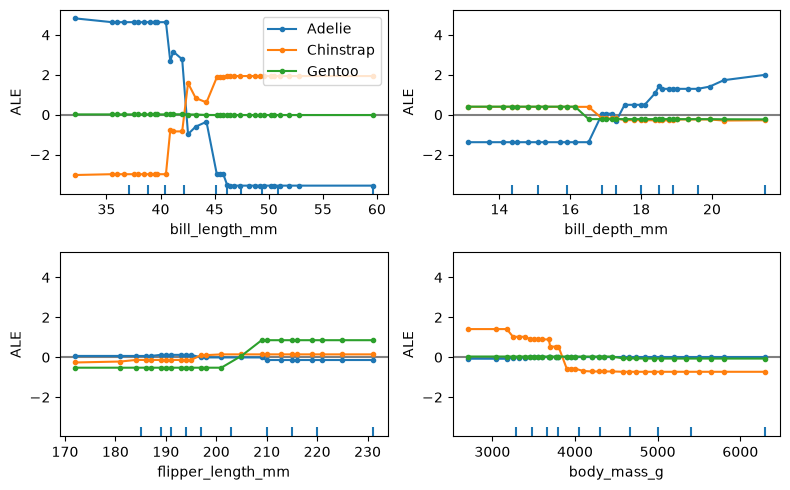

In [29]:
plot_ale(logit_exp_gb, n_cols=2, fig_kw={'figwidth': 8, 'figheight': 5});

Las curvas ALE ya no son lineales, dado que el modelo no es lineal.

Los ALE muestran que `bill_length_mm` y `bill_depth_mm` tienen un efecto importante sobre las predicciones.

Miremos qué dicen las **feature importances** del modelo:

In [30]:
pd.Series(
    gb.feature_importances_,
    index=feature_names_clean
).sort_values(ascending=False)

bill_length_mm       0.459703
flipper_length_mm    0.322190
island_Dream         0.114914
bill_depth_mm        0.040431
island_Torgersen     0.030550
island_Biscoe        0.028972
body_mass_g          0.003040
sex_Male             0.000139
sex_Female           0.000062
dtype: float64

**Por qué difiere el orden de las features**

`bill_length_mm` es tan dominante que destaca en ambas: en el ALE plot y en el ranking de `feature importance` (también en PFI, tal como vimos antes).

El resto de las features difieren en el ranking porque ALE y feature_importance **son cosas distintas**:
- feature_importances_: mide cuánta reducción total de impureza (Gini o Entropía) aportó esa variable en la construcción de la estructura.
- Gráficos ALE: Miden el efecto real de la variable en la predicción, sin importar cuántas veces se usó en los árboles.

### ALE en el espacio de probabilidades

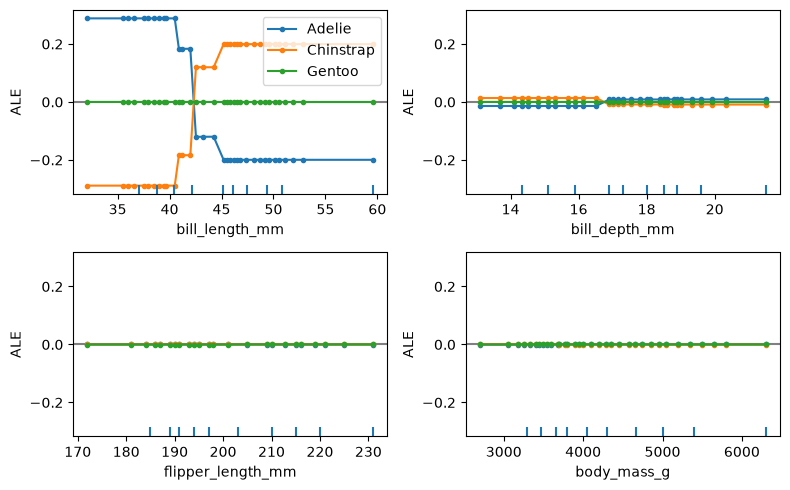

In [31]:
plot_ale(proba_exp_gb, n_cols=2, fig_kw={'figwidth': 8, 'figheight': 5});

### Comparación de ALE entre modelos

¿LR y Gradient Boosting aprenden la misma relación entre las features y la probabilidad de predecir cada una de las clases?

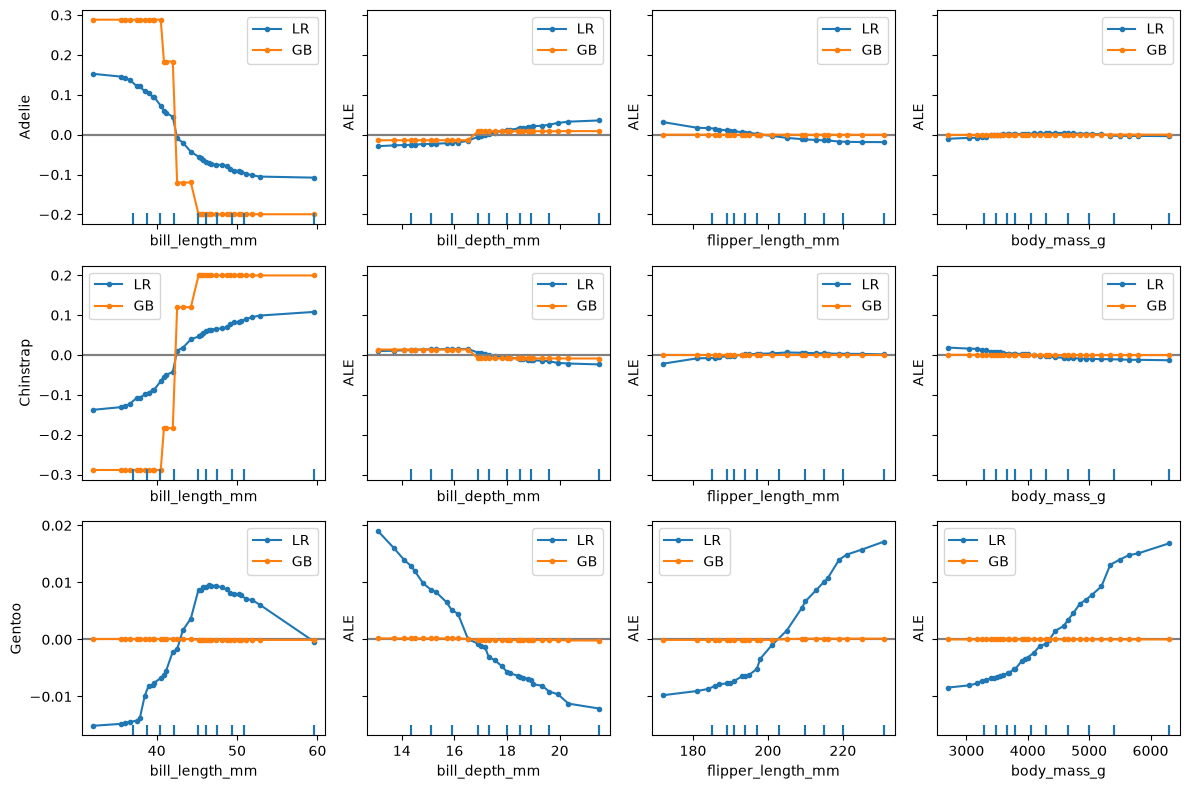

In [32]:
fig, ax = plt.subplots(
    3, 4,
    figsize=(12, 8),
    sharex='col',
    sharey='row'
)

features = [0, 1, 2, 3]
classes = ['Adelie', 'Chinstrap', 'Gentoo']

for i, target in enumerate(classes):
    for j, feature in enumerate(features):

        plot_ale(
            proba_exp,
            features=[feature],
            targets=[target],
            ax=ax[i, j],
            line_kw={'label': 'LR'}
        )

        plot_ale(
            proba_exp_gb,
            features=[feature],
            targets=[target],
            ax=ax[i, j],
            line_kw={'label': 'GB'}
        )

    ax[i, 0].set_ylabel(target)

for j, name in enumerate(feature_names[1:5]):
    ax[2, j].set_xlabel(name)
    
ax[0, 0].legend()
plt.tight_layout()

Cómo interpretamos los plots:
- horizontal: dada una especie (clase), cómo afecta cada una de las features a su predicción
- vertical: dada una feature, como afecta a la predicción de cada una de las tres especies
- LR vs GB: cómo cambia según el modelo.

**CONCLUSIONES**
- En el caso de Adelie y Chinstrap, ambos modelos coinciden en la dirección general para `bill_length_mm` (un pico largo favorece a una especie y castiga a la otra).
- Gradient Boosting parece no usar ninguna de las variables numéricas para predecir la clase Gentoo. Para este modelo, cambiar el valor de estas features no sube ni baja la probabilidad de que el pingüino sea un Gentoo. Probablemente el modelo ya aprendió a identificar a los Gentoo usando otras variables.
